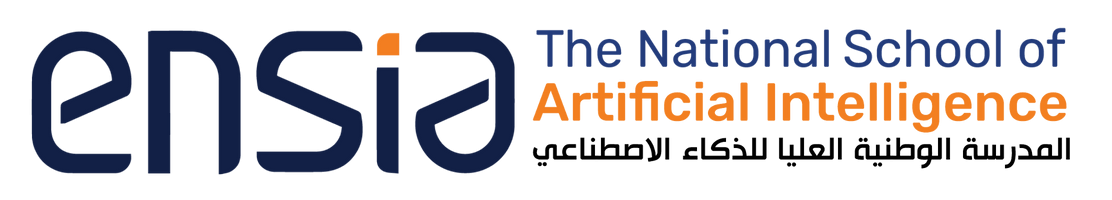

---
# **PART II: Introduction to Artificial Neural Networks**
---
Artificial Neural Networks (ANNs) are a class of machine learning models inspired by the biological structure of the brain. They consist of **layers of interconnected "neurons"** that process information through **weighted** connections. By adjusting these weights using optimization techniques such as **backpropagation** and **gradient descent**, ANNs are capable of learning complex, non-linear functions. Unlike traditional models like linear classifiers or SVMs, ANNs have the ability to **approximate** any continuous function, given sufficient depth and width, as guaranteed by the **[Universal Approximation Theorem](https://www.deep-mind.org/2023/03/26/the-universal-approximation-theorem/)**.

## The Three Main Components of an ANN

- **Input Layer:** Represents the input data.
- **Hidden Layers:** The internal architecture, including the number of layers, activation functions, learnable parameters, and other hyperparameters.
- **Output Layer:** Represents the network’s predictions or desired outputs.

In this lab, we will explore the fundamentals of neural networks. By the end of this lab, you should be able to:

- Identify the essential components that make up an ANN.
- Understand how information flows through these components.
- Understand how activation functions can be used to approximate other functions (e.g., using a Gaussian function as an example).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
%matplotlib inline

from PIL import Image

## Neural Networks

Suppose we have an input vector $X=${$x_1, x_2, ... x_L$} to a $k$-layered network. <BR><BR>
Each layer has its own number of nodes. For the first layer in our drawing that number is $J$. We can store the weights for each node in a vector $\mathbf{W} \in \mathbb{R}^{J \times (L+1)}$ (accounting for bias).  Similarly, we can store the biases from each node in a vector $\mathbf{b} \in \mathbb{R}^{I}$.  The affine transformation is then written as $$\mathbf{a} = \mathbf{W^T}X + \mathbf{b}$$ <BR>  What we then do is "absorb" $\mathbf{b}$ into $X$ by adding a column of ones to $X$. Our $X$ matrix than becomes $\mathbf{X} \in \mathbb{R}^{L+1}$ and our equation: <BR><BR>$$\mathbf{a} = \mathbf{W^T}_{plusones}X$$ <br>We have that $\mathbf{a} \in \mathbb{R}^{J}$ as well.  Next we evaluate the output from each node.  We write $$\mathbf{u} = \sigma\left(\mathbf{a}\right)$$ where $\mathbf{u}\in\mathbb{R}^{J}$.  We can think of $\sigma$ operating on each individual element of $\mathbf{a}$ separately or in matrix notation. If we denote each component of $\mathbf{a}$ by $a_{j}$ then we can write $$u_{j} = \sigma\left(a_{j}\right), \quad j = 1, ... J.$$<br> In our code we will implement all these equations in matrix notation.
`tf.keras` (Tensorflow) and `numpy` perform the calculations in matrix format.

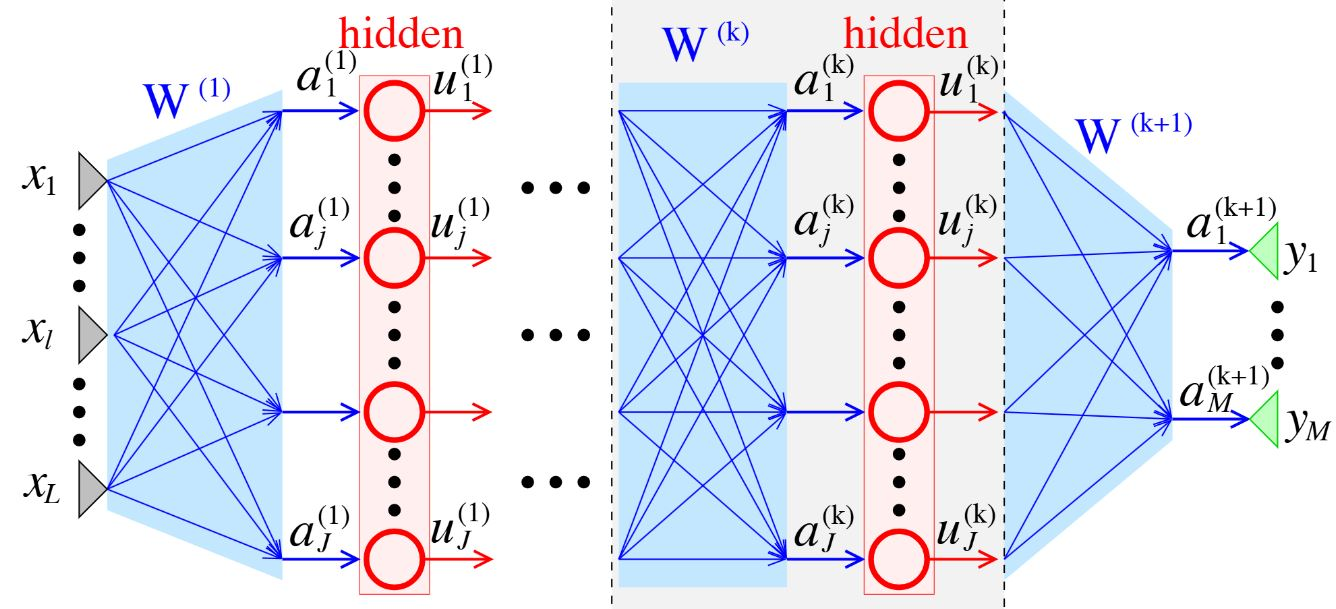

Let's assume that we have 3 input points (L = 3), two hidden layers ($k=2$), and 2 nodes in each layer ($J=2$)<br>

### Input Layer

$𝑋$={$𝑥_1,𝑥_2,x_3$}

### First Hidden Layer

\begin{equation}
 \begin{aligned}
a^{(1)}_1 = w^{(1)}_{10} + w^{(1)}_{11}x_1 + w^{(1)}_{12}x_2 + w^{(1)}_{13}x_3 \\
a^{(1)}_2 = w^{(1)}_{20} + w^{(1)}_{21}x_1 + w^{(1)}_{22}x_2 + w^{(1)}_{23}x_3 \\
\end{aligned}
\end{equation}
<br> All this in matrix notation: $$\mathbf{a} = \mathbf{W^T}X$$
<br> NOTE: in $X$ we have added a column of ones to account for the bias<BR><BR>
**Then the sigmoid is applied**:
\begin{equation}
 \begin{aligned}
u^{(1)}_1 = \sigma(a^{(1)}_1) \\
u^{(1)}_2 = \sigma(a^{(1)}_2) \\
\end{aligned}
\end{equation}
    
or in matrix notation: $$\mathbf{u} = \sigma\left(\mathbf{a}\right)$$

### Second Hidden Layer

\begin{equation}
 \begin{aligned}
a^{(2)}_1 = w^{(2)}_{10} + w^{(2)}_{11}u^{(1)}_1 + w^{(2)}_{12}u^{(1)}_2  \\
a^{(2)}_2 = w^{(2)}_{20} + w^{(2)}_{21}u^{(1)}_1 + w^{(2)}_{22}u^{(1)}_2  \\
\end{aligned}
\end{equation}
<br>

**Then the sigmoid is applied**:

\begin{equation}
 \begin{aligned}
u^{(2)}_1 = \sigma(a^{(2)}_1) \\
u^{(2)}_2 = \sigma(a^{(2)}_2) \\
\end{aligned}
\end{equation}

### Output Layer

#### If the output is categorical:

For example with four classes ($M=4$): $Y$={$y_1, y_2, y_3, y_4$}, we have the affine and then the sigmoid is lastly applied:

\begin{equation}
 \begin{aligned}
a^{(3)}_1 = w^{(3)}_{10} + w^{(3)}_{11}u^{(2)}_1 + w^{(3)}_{12}u^{(2)}_2 \\
a^{(3)}_2 = w^{(3)}_{20} + w^{(3)}_{21}u^{(2)}_1 + w^{(3)}_{22}u^{(2)}_2 \\
a^{(3)}_3 = w^{(3)}_{30} + w^{(3)}_{31}u^{(2)}_1 + w^{(3)}_{32}u^{(2)}_2 \\
a^{(3)}_4 = w^{(3)}_{40} + w^{(3)}_{41}u^{(2)}_1 + w^{(3)}_{42}u^{(2)}_2 \\
\end{aligned}
\end{equation}
<br>
\begin{equation}
 \begin{aligned}
y_1 = \sigma(a^{(3)}_1) \\
y_2 = \sigma(a^{(3)}_2) \\
y_3 = \sigma(a^{(3)}_3) \\
y_3 = \sigma(a^{(3)}_4) \\
\end{aligned}
\end{equation}
$\sigma$ will be softmax in the case of multiple classes and sigmoid for binary.
<BR>
    
#### If the output is a number (regression):

We have a single y as output:

\begin{equation}
 \begin{aligned}
y = w^{(3)}_{10}+ w^{(3)}_{11}u^{(2)}_1 + w^{(3)}_{12}u^{(2)}_2 \\
\end{aligned}
\end{equation}


<div class="exercise"><b>1. Plot the sigmoid</b></div>

Define the `sigmoid` and the `tanh`. For `tanh` you may use `np.tanh` and for the `sigmoid` use the general equation:
\begin{align}
\sigma = \dfrac{1}{1+e^{-2(x-c)/a}} \qquad\text{(1.1)}
\textrm{}
\end{align}

Generate a list of 500 $x$ points from -5 to 5 and plot both functions. What do you observe? What do variables $c$ and $a$ do?

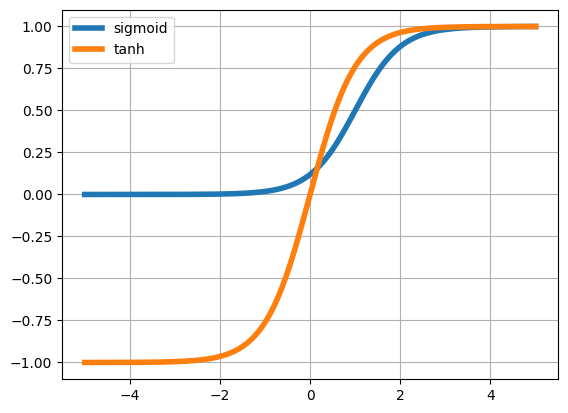

In [14]:
# The smaller the `a`, the sharper the function is.
# Variable `c` moves the function along the x axis
def sigmoid(x,c,a):
    z = ((x-c)/a)
    return 1.0 / (1.0 + np.exp(-z))

x = np.linspace(-5.0, 5.0, 500) # input points
c = 1.
a = 0.5

plt.figure()
plt.plot(x, sigmoid(x, c, a), lw=4, label='sigmoid')  # TODO: Plot the sigmoid function
plt.plot(x, np.tanh(x), lw=4, label='tanh')  # TODO: Plot the tanh function using numpy's implementation
plt.grid();
plt.legend();

<div class="exercise"><b>2. Approximate a Gaussian function using a node and manually adjusting the weights. Start with one layer with one node and move to two nodes.</b></div>

The task is to approximate (learn) a function $f\left(x\right)$ given some input $x$.  For demonstration purposes, the function we will try to learn is a Gaussian function:
\begin{align}
f\left(x\right) = e^{-x^{2}}
\textrm{}
\end{align}

Even though we represent the input $x$ as a vector on the computer, you should think of it as a single input.  

#### 2.1 Start by plotting the above function using the $x$ dataset you created earlier

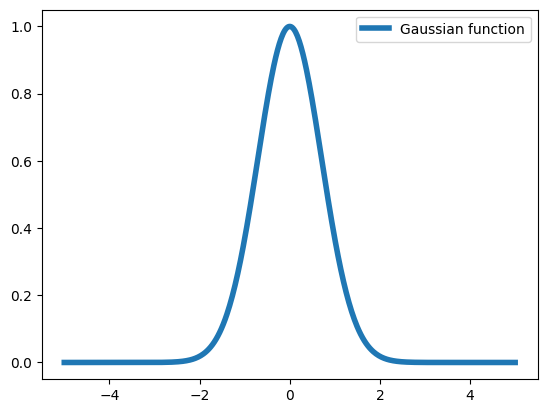

In [15]:
x = np.linspace(-5.0, 5.0, 500) # input points
def gaussian(x):
    return np.exp(-x**2)  # TODO: Define a Gaussian function that returns e^(-x²)

f = gaussian(x)  # TODO: Apply the Gaussian function to all input points

plt.figure()
plt.plot(x, f, lw=4, label='Gaussian function')  # TODO: Plot the Gaussian function
plt.legend()

In [16]:
f.shape

(500,)

#### 2.2 Now, let's code the single node as per the image above.

Write a function named `affine` that does the transformation. The definition is provided below. Then create a simpler sigmoid with just one variable. We choose a **sigmoid** activation function and specifically the **logistic** function.  Sigmoids are a family of functions and the logistic function is just one member in that family. $$\sigma\left(z\right) = \dfrac{1}{1 + e^{-z}}.$$ <br>

Define both functions in code.

In [17]:
def affine(x, w, b):
    """Return affine transformation of x

    INPUTS
    ======
    x: A numpy array of points in x
    w: An array representing the weight of the perceptron
    b: An array representing the biases of the perceptron

    RETURN
    ======
    z: A numpy array of points after the affine transformation
       z = wx + b
    """

    return w*x + b  # TODO: Define an affine transformation function that computes wx + b

In [18]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))  # TODO: Define the sigmoid activation function that computes σ(z) = 1/(1+e^(-z))

And now we plot the activation function and the true function. What do you think will happen if you change $w$ and $b$?

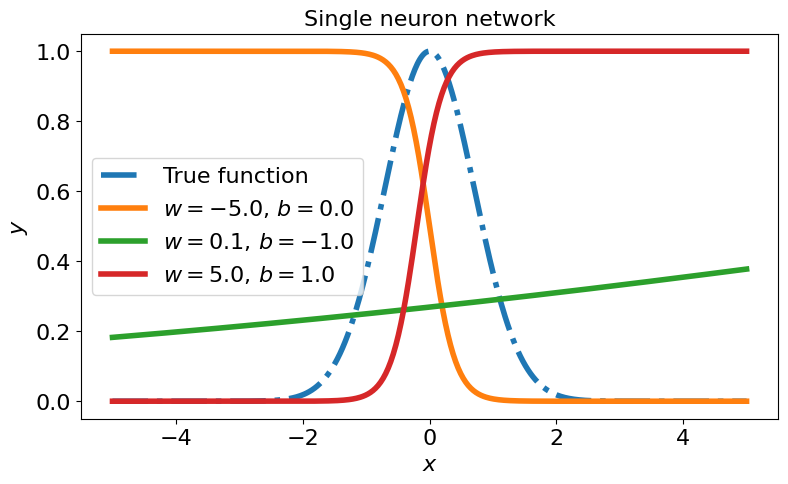

In [19]:
# Define lists of weights and biases to test different neuron configurations
w = [-5.0, 0.1, 5.0] # Create a list of weights
b = [0.0, -1.0, 1.0] # Create a list of biases

fig, ax = plt.subplots(1,1, figsize=(9,5))
SIZE = 16

# Plot the original Gaussian function as the "true" function
ax.plot(x, f, lw=4, ls='-.', label='True function')

# plot 3 "networks"
for wi, bi in zip(w, b):
    h = sigmoid(affine(x, wi, bi))  # TODO: Plot multiple sigmoid neurons with different weight and bias combinations
    ax.plot(x, h, lw=4, label=r'$w = {0}$, $b = {1}$'.format(wi,bi))

ax.set_title('Single neuron network', fontsize=SIZE)

# Create labels (very important!)
ax.set_xlabel('$x$', fontsize=SIZE) # Notice we make the labels big enough to read
ax.set_ylabel('$y$', fontsize=SIZE)

ax.tick_params(labelsize=SIZE) # Make the tick labels big enough to read

ax.legend(fontsize=SIZE, loc='best') # Create a legend and make it big enough to read

We didn't do an exhaustive search of the weights and biases, but it sure looks like this single perceptron is never going to match the actual function.  Again, we shouldn't be suprised about this.  The output layer of the network is simple the logistic function, which can only have so much flexibility.

Let's try to make our network more flexible by using **more nodes**!

### Multiple Perceptrons in a Single Layer
It appears that a single neuron is somewhat limited in what it can accomplish.  What if we expand the number of nodes/neurons in our network?  We have two obvious choices here.  One option is to add depth to the network by putting layers next to each other.  The other option is to stack neurons on top of each other in the same layer.  Now the network has some width, but is still only one layer deep.

In [20]:
# Create a perceptron network with multiple neurons in a single layer to better approximate the Gaussian function
x = np.linspace(-5.0, 5.0, 500) # input points
f = np.exp(-x*x) # data

# Define weights for two neurons in a single layer
w = np.array([3.5, -3.5])
# Define biases for the two neurons
b = np.array([3.5, 3.5])

# Affine transformations
z1 = affine(x, w[0], b[0])  # TODO: Compute the first neuron's pre-activation
z2 = affine(x, w[1], b[1])  # TODO: Compute the second neuron's pre-activation

# Node outputs
h1 = sigmoid(z1)  # TODO: Apply sigmoid activation to first neuron
h2 = sigmoid(z2)  # TODO: Apply sigmoid activation to second neuron

Now let's plot things and see what they look like.

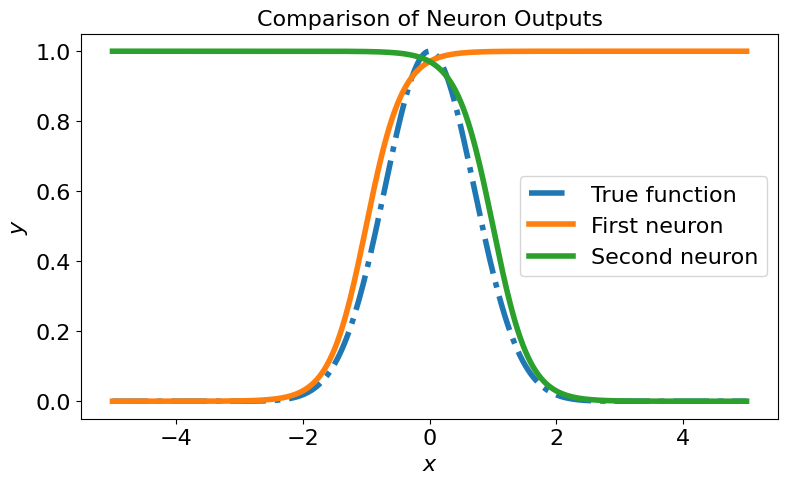

In [21]:
fig, ax = plt.subplots(1,1, figsize=(9,5))

ax.plot(x, f, lw=4, ls = '-.', label='True function')
ax.plot(x, h1, lw=4, label='First neuron')
ax.plot(x, h2, lw=4, label='Second neuron')

# Set title
ax.set_title('Comparison of Neuron Outputs', fontsize=SIZE)

# Create labels (very important!)
ax.set_xlabel('$x$', fontsize=SIZE) # Notice we make the labels big enough to read
ax.set_ylabel('$y$', fontsize=SIZE)

ax.tick_params(labelsize=SIZE) # Make the tick labels big enough to read

ax.legend(fontsize=SIZE, loc='best') # Create a legend and make it big enough to read

Just as we expected.  Some sigmoids.  Of course, to get the network prediction we must combine these two sigmoid curves somehow.  First we'll just add $h_{1}$ and $h_{2}$ without any weights to see what happens.

#### Note
We are **not** doing classification here.  We are trying to predict an actual function.  The sigmoid activation is convenient when doing classification because you need to go from $0$ to $1$.  However, when learning a function, we don't have as good of a reason to choose a sigmoid.

In [22]:
# Network output
wout = np.ones(2) # Set the output weights to unity (1)to begin
bout = -1 # Set a negative bias value for the output
yout = wout[0]*h1 + wout[1]*h2 + bout  # TODO: Calculate network output by combining weighted neuron outputs plus bias


And plot.

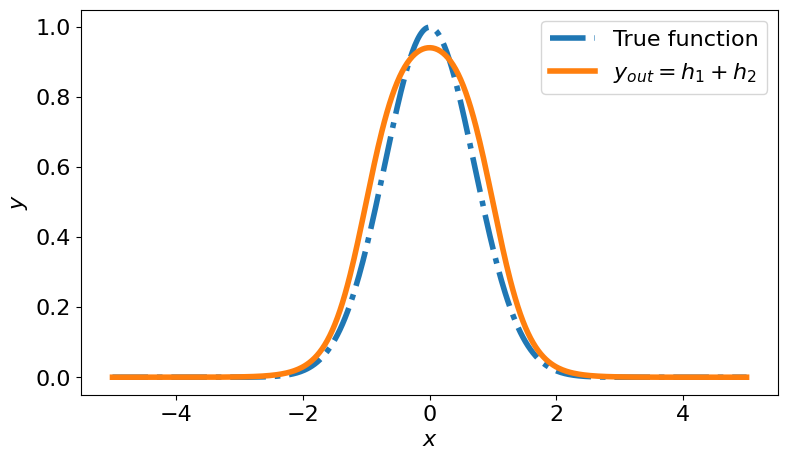

In [23]:
fig, ax = plt.subplots(1,1, figsize=(9,5))

ax.plot(x, f, ls='-.', lw=4, label=r'True function')
ax.plot(x, yout, lw=4, label=r'$y_{out} = h_{1} + h_{2}$')

# Create labels (very important!)
ax.set_xlabel('$x$', fontsize=SIZE) # Notice we make the labels big enough to read
ax.set_ylabel('$y$', fontsize=SIZE)

ax.tick_params(labelsize=SIZE) # Make the tick labels big enough to read

ax.legend(fontsize=SIZE, loc='best') # Create a legend and make it big enough to read

Very cool!  The two nodes interact with each other to produce a pretty complicated-looking function.  It still doesn't match the true function, but now we have some hope.  In fact, it's starting to look a little bit like a Gaussian!

We can do better.  There are three obvious options at this point:
1. Change the number of nodes
2. Change the activation functions
3. Change the weights

#### We will leave this simple example for some other time.